## Clustering with K-Means

### Objective and notation

K-Means tries to partition the data into $k$ clusters by minimizing the sum of squared distances to cluster centroids. Let:
- $k$ = number of clusters
- Centroids: $c_1, \dots, c_k \in \mathbb{R}^n$
- Cluster assignment of point $x_i$: $z_i \in \{1, \dots, k\}$

Objective (inertia):
$$
J(c_1,\dots,c_k, z_1,\dots,z_m)
  = \sum_{i=1}^{m} \left\| x_i - c_{z_i} \right\|^2
$$

We want to minimize $J$.

### Algorithm (Lloyd’s algorithm)

Iterate until convergence:
1. **Assignment step**: assign each point to the closest centroid:
   $$
   z_i = \arg\min_{j \in \{1,\dots,k\}} \|x_i - c_j\|^2.
   $$
2. **Update step**: recompute each centroid as the mean of its assigned points:
   $$
   c_j = \frac{1}{|C_j|} \sum_{i: z_i = j} x_i,
   $$
   where $C_j$ is the set of indices of points currently assigned to cluster $j$.

K-Means converges to a local minimum of $J$, not necessarily the global one, and the result depends on initialization.

### Hard vs soft clustering (distances)

K-Means is a **hard** clustering algorithm: each point belongs to exactly one cluster. But you can still compute distances to all centroids to measure “softness”.

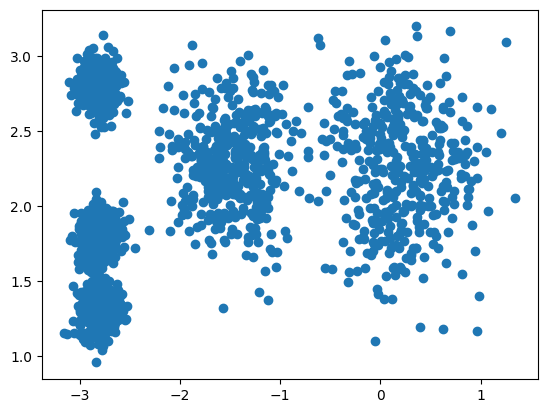

In [3]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt


blob_centers = np.array([
    [ 0.2,  2.3], 
	[-1.5 ,  2.3], 
	[-2.8,  1.8],
	[-2.8,  2.8], 
	[-2.8,  1.3]
])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(
    n_samples=2000, 
	centers=blob_centers, 
	cluster_std=blob_std,
    random_state=7
)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

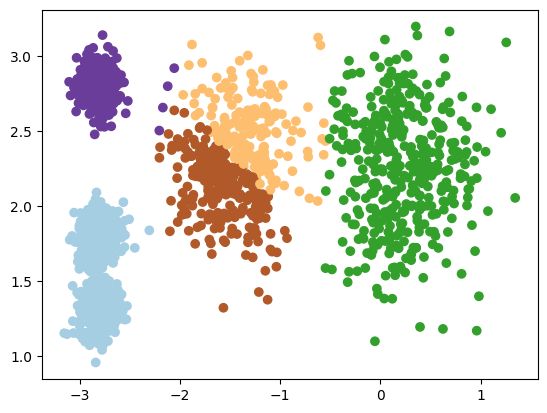

In [5]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=123)
y_pred = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="Paired")
plt.show()

In [6]:
centroids = kmeans.cluster_centers_
centroids

array([[-2.80301764,  1.5512747 ],
       [ 0.22087068,  2.2520394 ],
       [-1.29409964,  2.52072848],
       [-2.7943747 ,  2.79740645],
       [-1.58531424,  2.10454596]])

`kmeans.transform(X_new)` returns the Euclidean distance from each new point to each centroid. Hard prediction `predict` simply takes the index of the smallest distance.

In [7]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
distances = kmeans.transform(X_new) # shape = (len(X_new), k), distances to centroids
distances

array([[2.83870785, 0.33512344, 1.394938  , 2.90592274, 1.58875772],
       [5.82034089, 2.79053465, 4.32555775, 5.84898582, 4.58650592],
       [1.46205576, 3.30657723, 1.7719473 , 0.28866228, 1.67426812],
       [0.9689591 , 3.23040128, 1.70602629, 0.3615693 , 1.46891787]])

The **Radial Basis Function (RBF) Kernel**, also known as the **Gaussian Kernel**:

$$K(\mathbf{x}, \mathbf{z}) = \frac{1}{e^\frac{\|\mathbf{x} - \mathbf{z}\|^2}{2\sigma^2}}= \frac{1}{e^\frac{d(\mathbf{x},\mathbf{z})^2}{2\sigma^2}}
$$

Or with parameter $\gamma = \frac{1}{2\sigma^2}$:

$$K(\mathbf{x}, \mathbf{z}) = \frac{1}{e^{\gamma \|\mathbf{x} - \mathbf{z}\|^2}}= \frac{1}{e^{\gamma \ d(\mathbf{x},\mathbf{z})^2}}
$$

Properties: 
1. **Similarity Measure**: Returns values in $(0, 1]$
   - $K = 1$ when $\mathbf{x} = \mathbf{z}$ (identical points)
   - $K \to 0$ as $\|\mathbf{x} - \mathbf{z}\| \to \infty$

2. **Radial Symmetry**: Depends only on distance from center


In [8]:
from sklearn.metrics.pairwise import rbf_kernel
rbf_kernel(X_new, kmeans.cluster_centers_, gamma=0.5).round(3)

array([[0.018, 0.945, 0.378, 0.015, 0.283],
       [0.   , 0.02 , 0.   , 0.   , 0.   ],
       [0.343, 0.004, 0.208, 0.959, 0.246],
       [0.625, 0.005, 0.233, 0.937, 0.34 ]])

### Inertia and the K-Means score

The **inertia** is exactly the objective $J$:
$$
\text{inertia} = \sum_{i=1}^m \|x_i - c_{z_i}\|^2.
$$

In [9]:
kmeans.inertia_, kmeans.score(X) # = -inertia

(236.96817790320995, -236.96817790320995)

In [10]:
np.sum(np.linalg.norm(X - centroids[y_pred], axis=1)**2)

np.float64(236.96817790321)

The score is negative because scikit‑learn follows a “larger is better” convention for `score`. So:
- lower inertia → better clustering
- higher `score` (less negative) → better clustering


### Multiple initializations and K-Means++

Because K-Means can get stuck in bad local minima, we typically:
- run it several times with different initial centroids
- keep the solution with lowest inertia

Scikit‑learn does this automatically via `n_init`:

In [11]:
kmeans = KMeans(
    n_clusters=5,
    init="random",   # or "k-means++" (default)
    n_init=10,
    random_state=42,
)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'



**K-Means++** is a smarter initialization:
- pick first centroid randomly
- then pick each next centroid with probability proportional to squared distance to nearest existing centroid

This spreads out centroids and reduces the chance of poor local minima. In scikit‑learn this is the default (`init="k-means++"`).

### Mini-Batch K-Means

When $m$ is huge, full K-Means becomes expensive. **Mini‑Batch K-Means** approximates K-Means by using small random batches at each iteration.

Key ideas:
- Sample a mini‑batch of size `batch_size`
- Assign those sampled points to centroids
- Update centroids using just that mini‑batch (like a stochastic gradient step)

In [12]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

minibatch_kmeans.inertia_

211.6594510571261

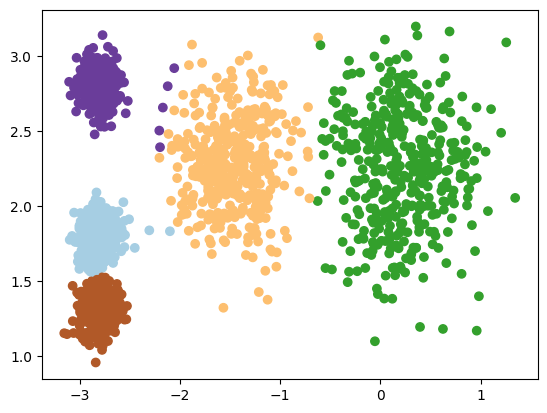

In [13]:
y_pred = minibatch_kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="Paired")
plt.show()


For out‑of‑core data (e.g., MNIST on disk), you can use `np.memmap` plus `MiniBatchKMeans` to iterate over the data in chunks.

## Choosing k: Elbow and Silhouette

K-Means requires choosing $k$. Two common heuristics are:
- Elbow method (using inertia)
- Silhouette score

### Elbow method

Compute inertia for many values of $k$ and look for a point where the curve “bends”:


In [18]:
inertias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

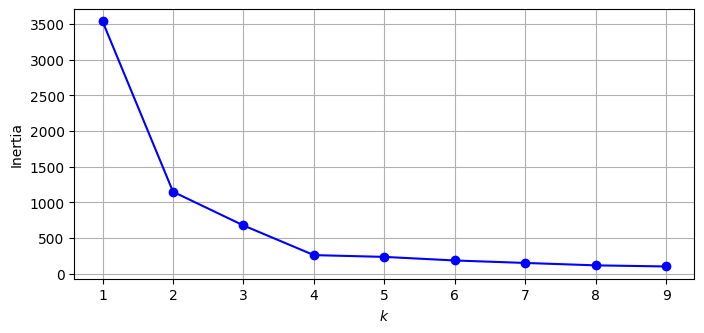

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.grid()



Plot inertia vs $k$:
- inertia decreases as $k$ increases
- “elbow” is where adding more clusters does not reduce inertia much

Mathematically, there is no optimality guarantee; it is a visual heuristic.



### Silhouette coefficient and score

For a single point $x_i$:
- Let $a_i$ be the mean distance from $x_i$ to other points in the same cluster (intra‑cluster distance).
- Let $b_i$ be the mean distance from $x_i$ to points in the nearest other cluster.

The **silhouette coefficient**:
$$
s_i = \frac{b_i - a_i}{\max(a_i, b_i)}.
$$

Range:
- $s_i \approx 1$: well inside its cluster, far from others
- $s_i \approx 0$: on the border between clusters
- $s_i < 0$: probably misclassified

The **silhouette score** is the average $s_i$ over all points. Higher is better.

In [20]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=43)
kmeans.fit(X)
score = silhouette_score(X, kmeans.labels_)
score

0.688531617595759

You can compute scores for several $k$ and pick those with high silhouette.
The notebook also shows **silhouette plots**: they visualize the distribution of $s_i$ values within each cluster, giving more insight than a single average.

## Limits of K-Means

K-Means assumes:
- clusters are roughly spherical (in Euclidean space)
- clusters have similar size and density
- you know $k$

It struggles when:
- clusters are elongated or of very different densities
- clusters are non‑convex (e.g. moon shapes)
- there is a lot of noise/outliers

The notebook demonstrates this by constructing an elongated + dense cluster mixture and showing K-Means’ decision boundaries can be misleading, even if inertia is low.

## Gaussian Mixture Models (GMM)

K-Means clusters by distance to centroids and gives **hard** assignments. Gaussian Mixture Models:
- assume data is generated from a mixture of $k$ Gaussians
- provide **soft** assignments: posterior probabilities $p(\text{cluster } j \mid x)$

### Model

Assume:
$$
p(x) = \sum_{j=1}^{k} \pi_j \,\mathcal{N}(x \mid \mu_j, \Sigma_j),
$$
where:
- $\pi_j$ are mixing coefficients, $\sum_j \pi_j = 1,\ \pi_j \ge 0$
- $\mu_j$ are means
- $\Sigma_j$ are covariance matrices

Given parameters $\theta = (\pi_j, \mu_j, \Sigma_j)$, the **responsibility** of component $j$ for point $x_i$ is:
$$
\gamma_{ij} = p(z_i = j \mid x_i;\theta)
  = \frac{\pi_j \,\mathcal{N}(x_i \mid \mu_j, \Sigma_j)}{\sum_{\ell=1}^{k} \pi_\ell \,\mathcal{N}(x_i \mid \mu_\ell, \Sigma_\ell)}.
$$

### EM algorithm (high level)

GMM parameters are typically learned by **Expectation–Maximization**:
1. Initialize parameters $\theta^{(0)}$.
2. Repeat until convergence:
   - E‑step: compute responsibilities $\gamma_{ij}$ given current parameters.
   - M‑step: update $\pi_j, \mu_j, \Sigma_j$ by maximizing the expected complete‑data log‑likelihood weighted by $\gamma_{ij}$.

You do not need to derive the updates by hand; scikit‑learn handles this.

### GMM vs K-Means

- K-Means: partition space into Voronoi cells; each point belongs to exactly one cluster; clusters are spherical in feature space.
- GMM: each point belongs to each cluster with some probability; cluster shapes can be ellipses (full covariance) or constrained (diag, tied, spherical).
- K-Means is GMM with equal spherical covariances and hard assignments.

In [21]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=123)
y_cluster = gmm.fit_predict(X)
y_cluster

array([0, 0, 1, ..., 3, 1, 0], shape=(2000,))

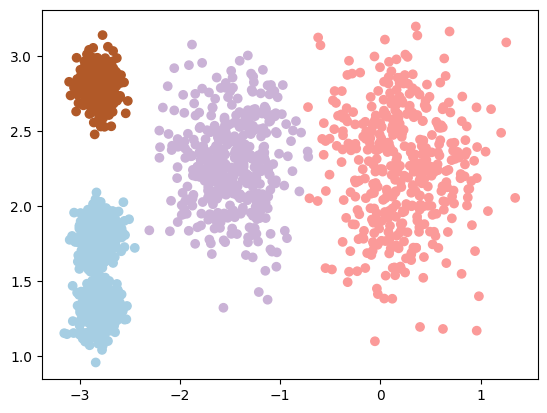

In [22]:
plt.scatter(X[:, 0], X[:, 1], c=y_cluster, cmap="Paired")

Key methods:
- `fit`, `predict` → hard cluster assignment
- `predict_proba(X)` → soft probabilities $\gamma_{ij}$

We cannot use the inertia or the silhouette score because they both assume that the clusters are spherical. Instead, we can try to find the model that minimizes a theoretical information criterion such as the Bayesian Information Criterion (BIC) or the Akaike Information Criterion (AIC):

${BIC} = {\log(m)p - 2\log({\hat L})}$

${AIC} = 2p - 2\log(\hat L)$

* $m$ is the number of instances.
* $p$ is the number of parameters learned by the model.
* $\hat L$ is the maximized value of the likelihood function of the model. This is the conditional probability of the observed data $\mathbf{X}$, given the model and its optimized parameters.

Both BIC and AIC penalize models that have more parameters to learn (e.g., more clusters), and reward models that fit the data well (i.e., models that give a high likelihood to the observed data).

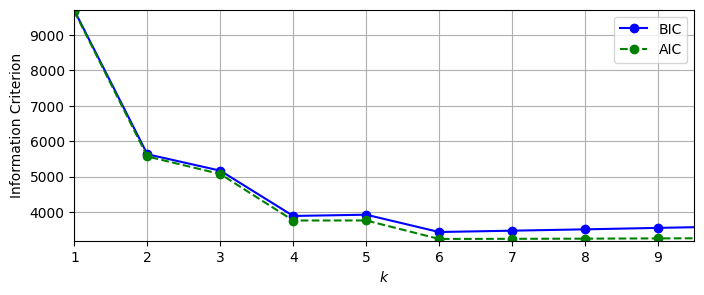

In [23]:
gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)]
bics = [model.bic(X) for model in gms_per_k]
aics = [model.aic(X) for model in gms_per_k]

plt.figure(figsize=(8, 3))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50, max(aics) + 50])
plt.legend()
plt.grid()

plt.show()

## DBSCAN

DBSCAN (Density‑Based Spatial Clustering of Applications with Noise) detects clusters as dense regions separated by low‑density areas. It:
- does not require $k$
- can find arbitrarily shaped clusters
- labels some points as noise

Parameters:
- `eps`: radius of the neighborhood
- `min_samples`: minimum number of points to form a dense region

Core ideas:
- A point is a **core point** if at least `min_samples` points are within distance `eps`.
- A point is **reachable** from a core point if there is a path of core points with neighbor distance ≤ `eps`.
- Points not reachable from any core point are labeled as noise.

Mathematically it is based on connectivity within an $\varepsilon$-neighborhood graph.

In [46]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=10)
dbscan.fit(X)

dbscan.labels_  # -1 = noise, 0..K-1 = cluster labels

array([ 0,  0, -1, ...,  2,  3,  0], shape=(2000,))

In [47]:
dbscan.core_sample_indices_

array([   0,    1,    3, ..., 1997, 1998, 1999], shape=(1918,))

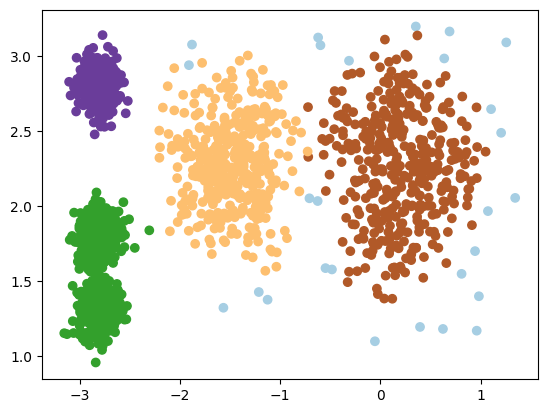

In [49]:
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap="Paired")

Use DBSCAN when:
- cluster shapes are complex (e.g., concentric circles, moons)
- you want automatic detection of number of clusters
- you are okay with labeling outliers as noise